# Biases: CESM3 / MOM6 experiment comparison

Additional bias diagnostics for a set of coupled and forced experiments,
beyond the ones already covered in `key_diagnostics.ipynb`. The shared
`Experiment` class lives in `experiment.py` so it can be reused across
notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import matplotlib.pyplot as plt
import cftime

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)

REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.

In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())
coupled_names = ['coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'CTRL' ]
forced_names = ['forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0', 'forced_CTRL']

print('\nInitialized:', exp_names)

[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [3]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

# 1. Temperature bias (model - obs)

Time-mean potential temperature bias against the WOA-2018 climatology
(`woa-2018-tx2_3v2-annual-all`), read directly from the precomputed
`thetao_bias` field in each experiment's `*_thetao_time_mean.nc`
(`model - obs`, generated by `mom6_tools.TS_levels`; see
[compare_runs_coupled.ipynb](../notebooks-development/compare_runs_coupled.ipynb)
for the original ad hoc version of this bias computation). Shown at the
surface level (`z_l` = 2.5 m). RMSE is the area-weighted RMS of the bias field
(`mom6_tools.m6plot.myStats`).

Same 2x3 grid / contourf / gray-land / shared-colorbar spatial-map style as
key_diagnostics.ipynb section 11 (surface epineutral diffusivity).

In [37]:
# Generic bias-map plotter, reused for temperature and salinity.
# Left column: GM control bias (model - obs).
# Other columns: response pattern of each experiment relative to GM (exp - GM).
%matplotlib inline
from mom6_tools.m6plot import myStats
import matplotlib as mpl

# GM control first in each row, then the two ANN experiments.
coupled_row = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_row = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


def plot_bias_maps(get_bias, target_depth, norm, cmap, quantity, unit,
                   cbar_label):
    """2x3 map of a bias field (model - obs) and exp - GM response patterns.

    ``get_bias(exp)`` returns the 3D bias DataArray (z_l, yh, xh) for an
    experiment. The nearest ``z_l`` level to ``target_depth`` (m) is selected.
    RMSE is always the area-weighted RMS of each experiment's bias against obs
    (exp - obs), even on panels that display the response pattern (exp - GM).
    """
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=150,
                             sharex=True, sharey=True, constrained_layout=True)
    pc = None
    depth = None
    for row, (regime, names) in enumerate([('Coupled', coupled_row),
                                           ('Forced', forced_row)]):
        gm_name = names[0]
        gm_bias = get_bias(exps[gm_name]).sel(z_l=target_depth, method='nearest')
        for col, name in enumerate(names):
            ax = axes[row, col]
            exp = exps[name]
            bias = get_bias(exp).sel(z_l=target_depth, method='nearest')
            depth = round(float(bias.z_l), 1)
            if col == 0:
                field = bias                     # GM control bias (model - obs)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' obs'
            else:
                field = bias - gm_bias           # response pattern (exp - GM)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
            area = np.ma.masked_invalid(exp.area)
            _, _, _, _, rmse = myStats(np.ma.masked_invalid(bias.values), area)
            # Plot on true geographic (lon, lat) coordinates from the MOM6 grid.
            # pcolormesh requires finite X/Y; fill NaN land points in the coords
            # with nearest valid grid values so coastal cells aren't distorted.
            ydim, xdim = exp.grd.geolon.dims
            lon = (exp.grd.geolon.ffill(xdim).bfill(xdim)
                   .ffill(ydim).bfill(ydim).values)
            lat = (exp.grd.geolat.ffill(ydim).bfill(ydim)
                   .ffill(xdim).bfill(xdim).values)
            pc = ax.pcolormesh(lon, lat, np.ma.masked_invalid(field.values),
                               cmap=cmap, norm=norm, shading='auto')
            ax.set_facecolor('gray')
            ax.set_title(f'{title}\nRMSE={rmse:.2f} {unit}')
            ax.set_xlabel('Longitude' if row == 1 else '')
            ax.set_ylabel('Latitude' if col == 0 else '')
    cbar = fig.colorbar(pc, ax=axes, label=cbar_label, extend='both',
                        ticks=norm.boundaries, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in norm.boundaries])
    fig.suptitle(f'{quantity} bias (model $-$ obs) and response patterns, '
                 f'depth={depth} m', fontsize=30)
    plt.show()


# --- Temperature configuration ---
TBIAS_LEVELS = np.arange(-1.8, 1.81, 0.4)   # degC, matches compare_runs_coupled.ipynb
T_CMAP = plt.get_cmap('RdYlBu_r')
T_NORM = mpl.colors.BoundaryNorm(TBIAS_LEVELS, T_CMAP.N, extend='both')


def plot_thetao_bias_maps(target_depth):
    plot_bias_maps(lambda e: e.thetao().thetao_bias, target_depth,
                   T_NORM, T_CMAP, 'Temperature', r'$^\circ$C',
                   r'Temperature bias or response [$^\circ$C]')


# --- Salinity configuration ---
# Wide neutral central bin: |bias| < 0.1 PSU is drawn as a single neutral
# color instead of flipping hue across zero. Boundaries are uneven (a fat
# [-0.1, 0.1] bin) and the matching bin color is set to white.
SBIAS_LEVELS = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, -0.1,
                         0.1, 0.2, 0.4, 0.6, 0.8, 1.0])   # PSU
_s_base = plt.get_cmap('RdYlBu_r')
_s_nbins = len(SBIAS_LEVELS) - 1
_s_colors = list(_s_base(np.linspace(0, 1, _s_nbins)))
_s_colors[_s_nbins // 2] = (1.0, 1.0, 1.0, 1.0)   # neutral for [-0.1, 0.1] PSU
S_CMAP = mpl.colors.ListedColormap(_s_colors)
S_CMAP.set_under(_s_base(0.0))
S_CMAP.set_over(_s_base(1.0))
S_NORM = mpl.colors.BoundaryNorm(SBIAS_LEVELS, S_CMAP.N)   # extend via colorbar


def plot_so_bias_maps(target_depth):
    plot_bias_maps(lambda e: e.so().so_bias, target_depth,
                   S_NORM, S_CMAP, 'Salinity', 'PSU',

                   'Salinity bias or response [PSU]')

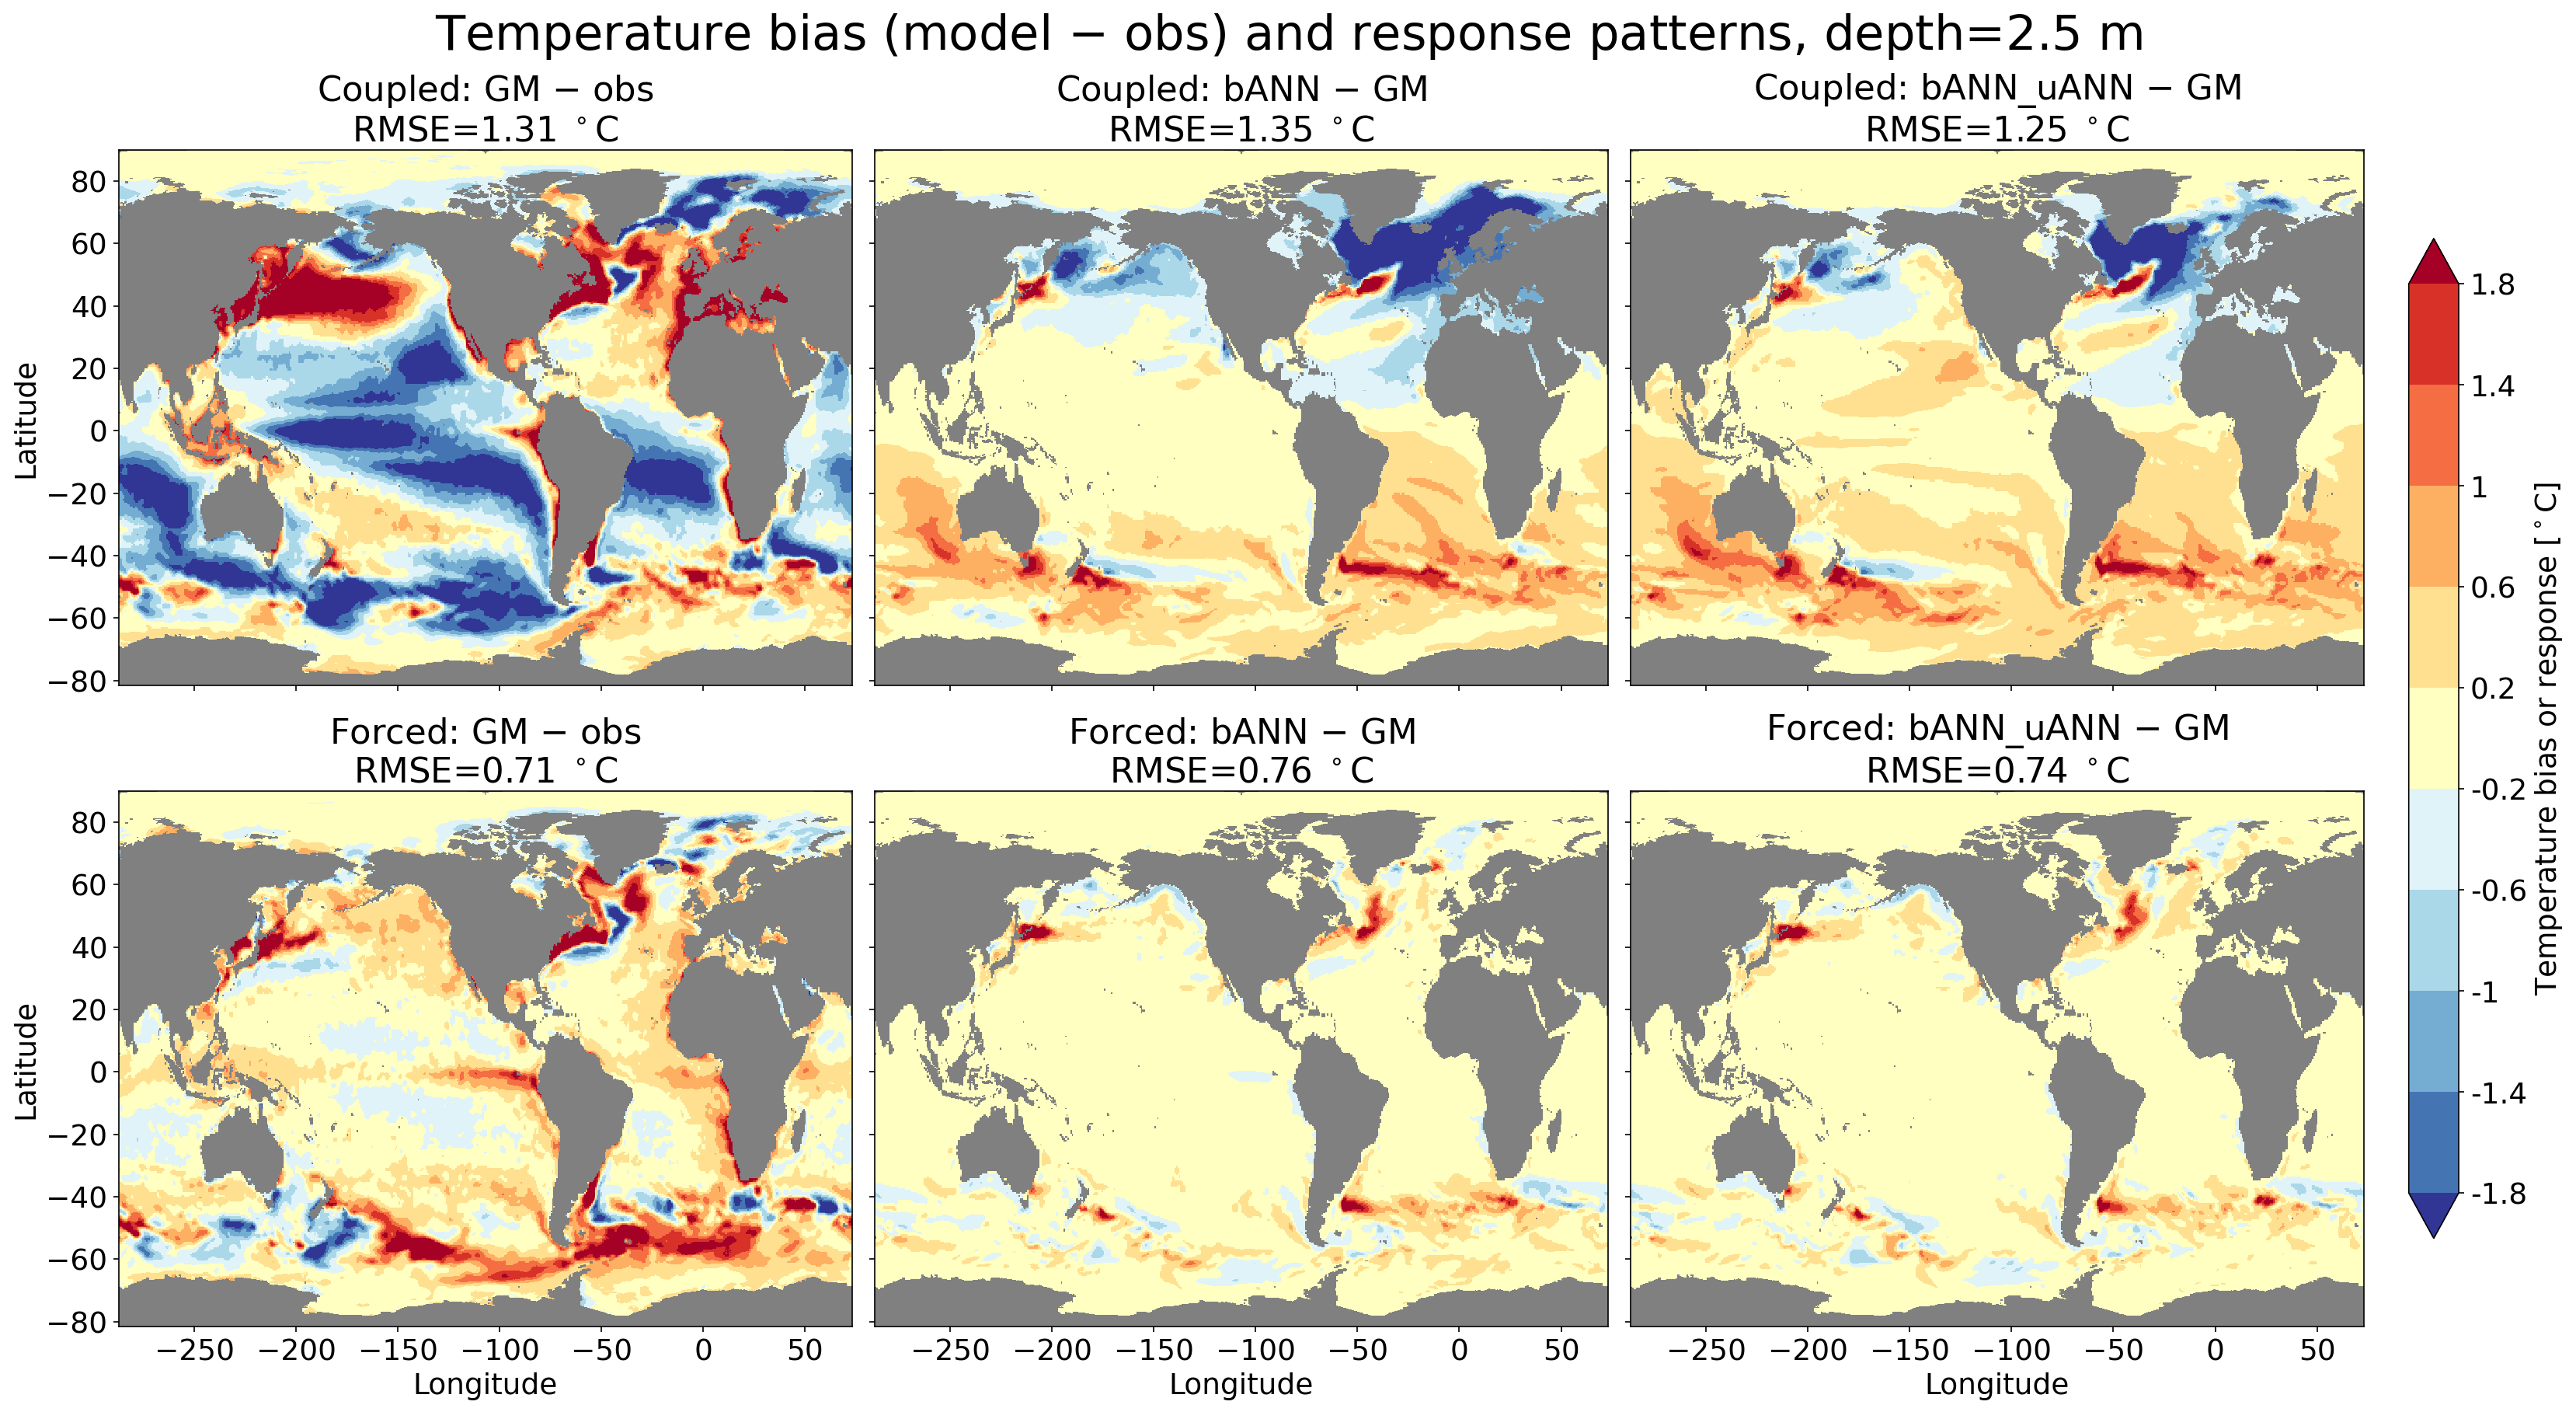

In [38]:
plot_thetao_bias_maps(2.5)   # surface (nearest z_l = 2.5 m)


# 2. Temperature bias (model - obs) at 250 m

Same diagnostic as section 1, but at ~250 m depth
(`z_l` selected by nearest value) instead of the surface.


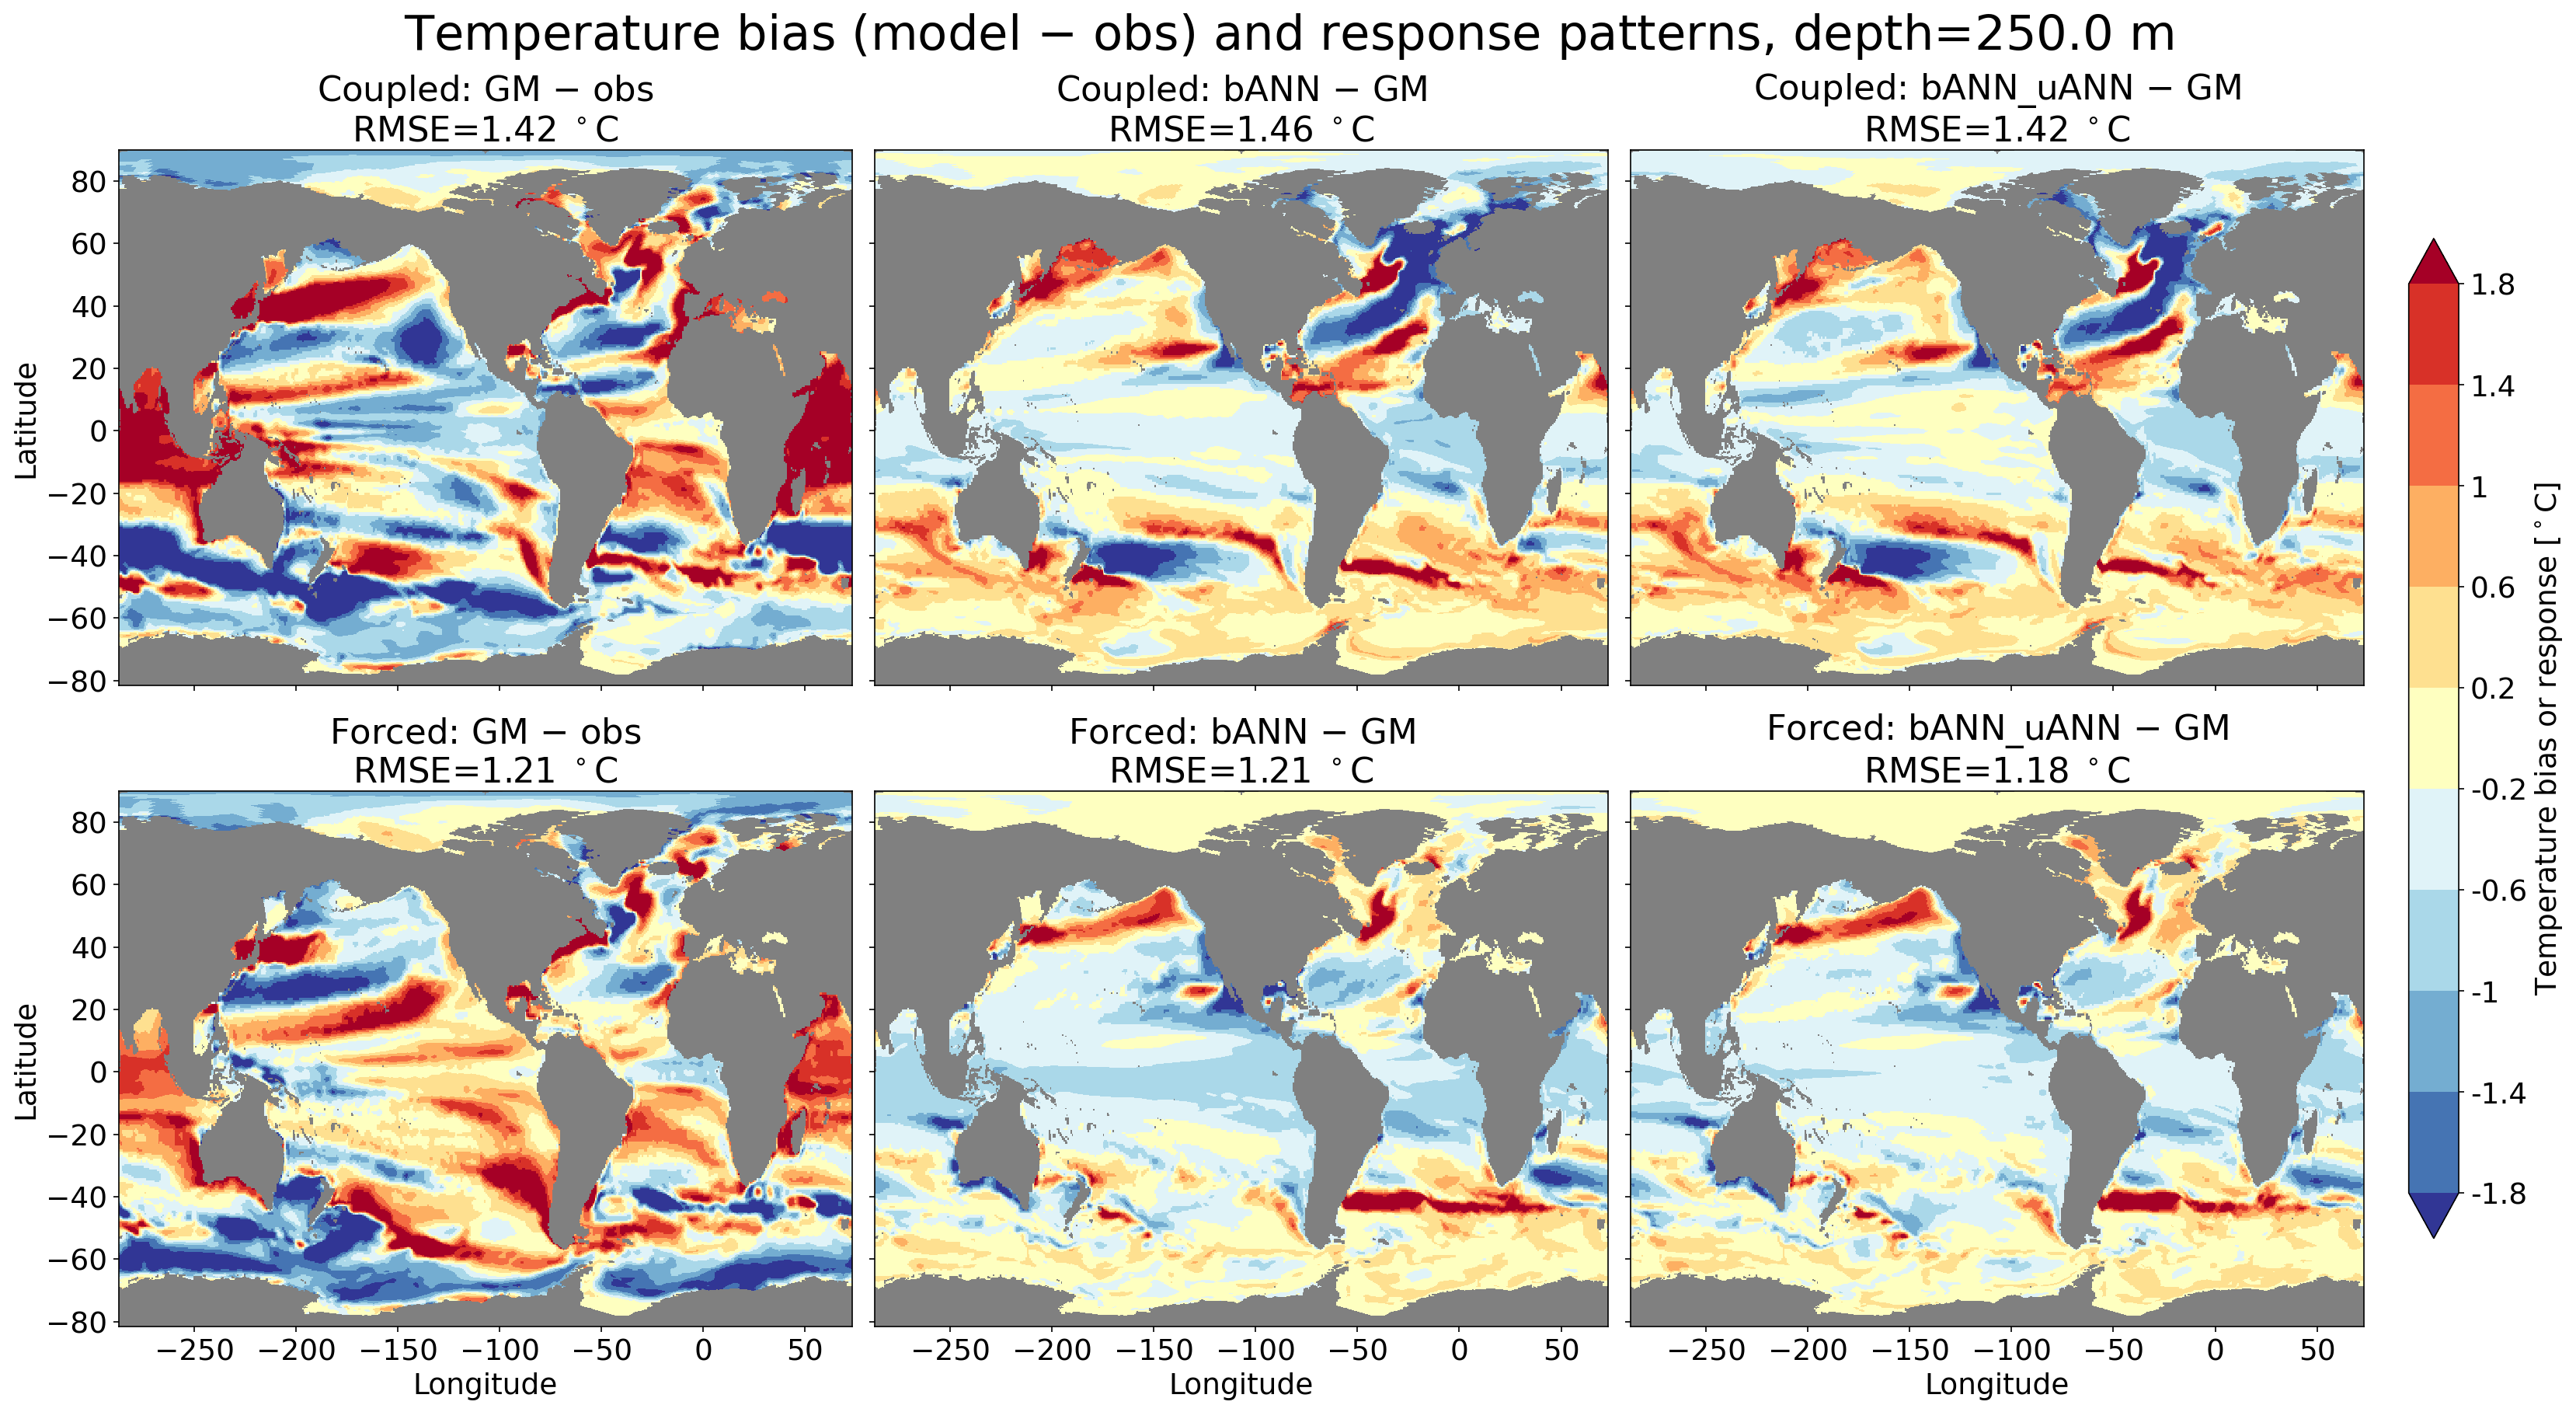

In [39]:
# Same diagnostic as section 1, at ~250 m (nearest z_l level).
plot_thetao_bias_maps(250.0)

# 3. Salinity bias (model - obs)

Same diagnostic as section 1 but for practical salinity, read from the
precomputed `so_bias` field in each experiment's `*_so_time_mean.nc`
(`model - obs`, generated by `mom6_tools.TS_levels` against the WOA-2018
climatology). Shown at the surface level (nearest `z_l` = 2.5 m). RMSE is the
area-weighted RMS of the bias field (`mom6_tools.m6plot.myStats`).


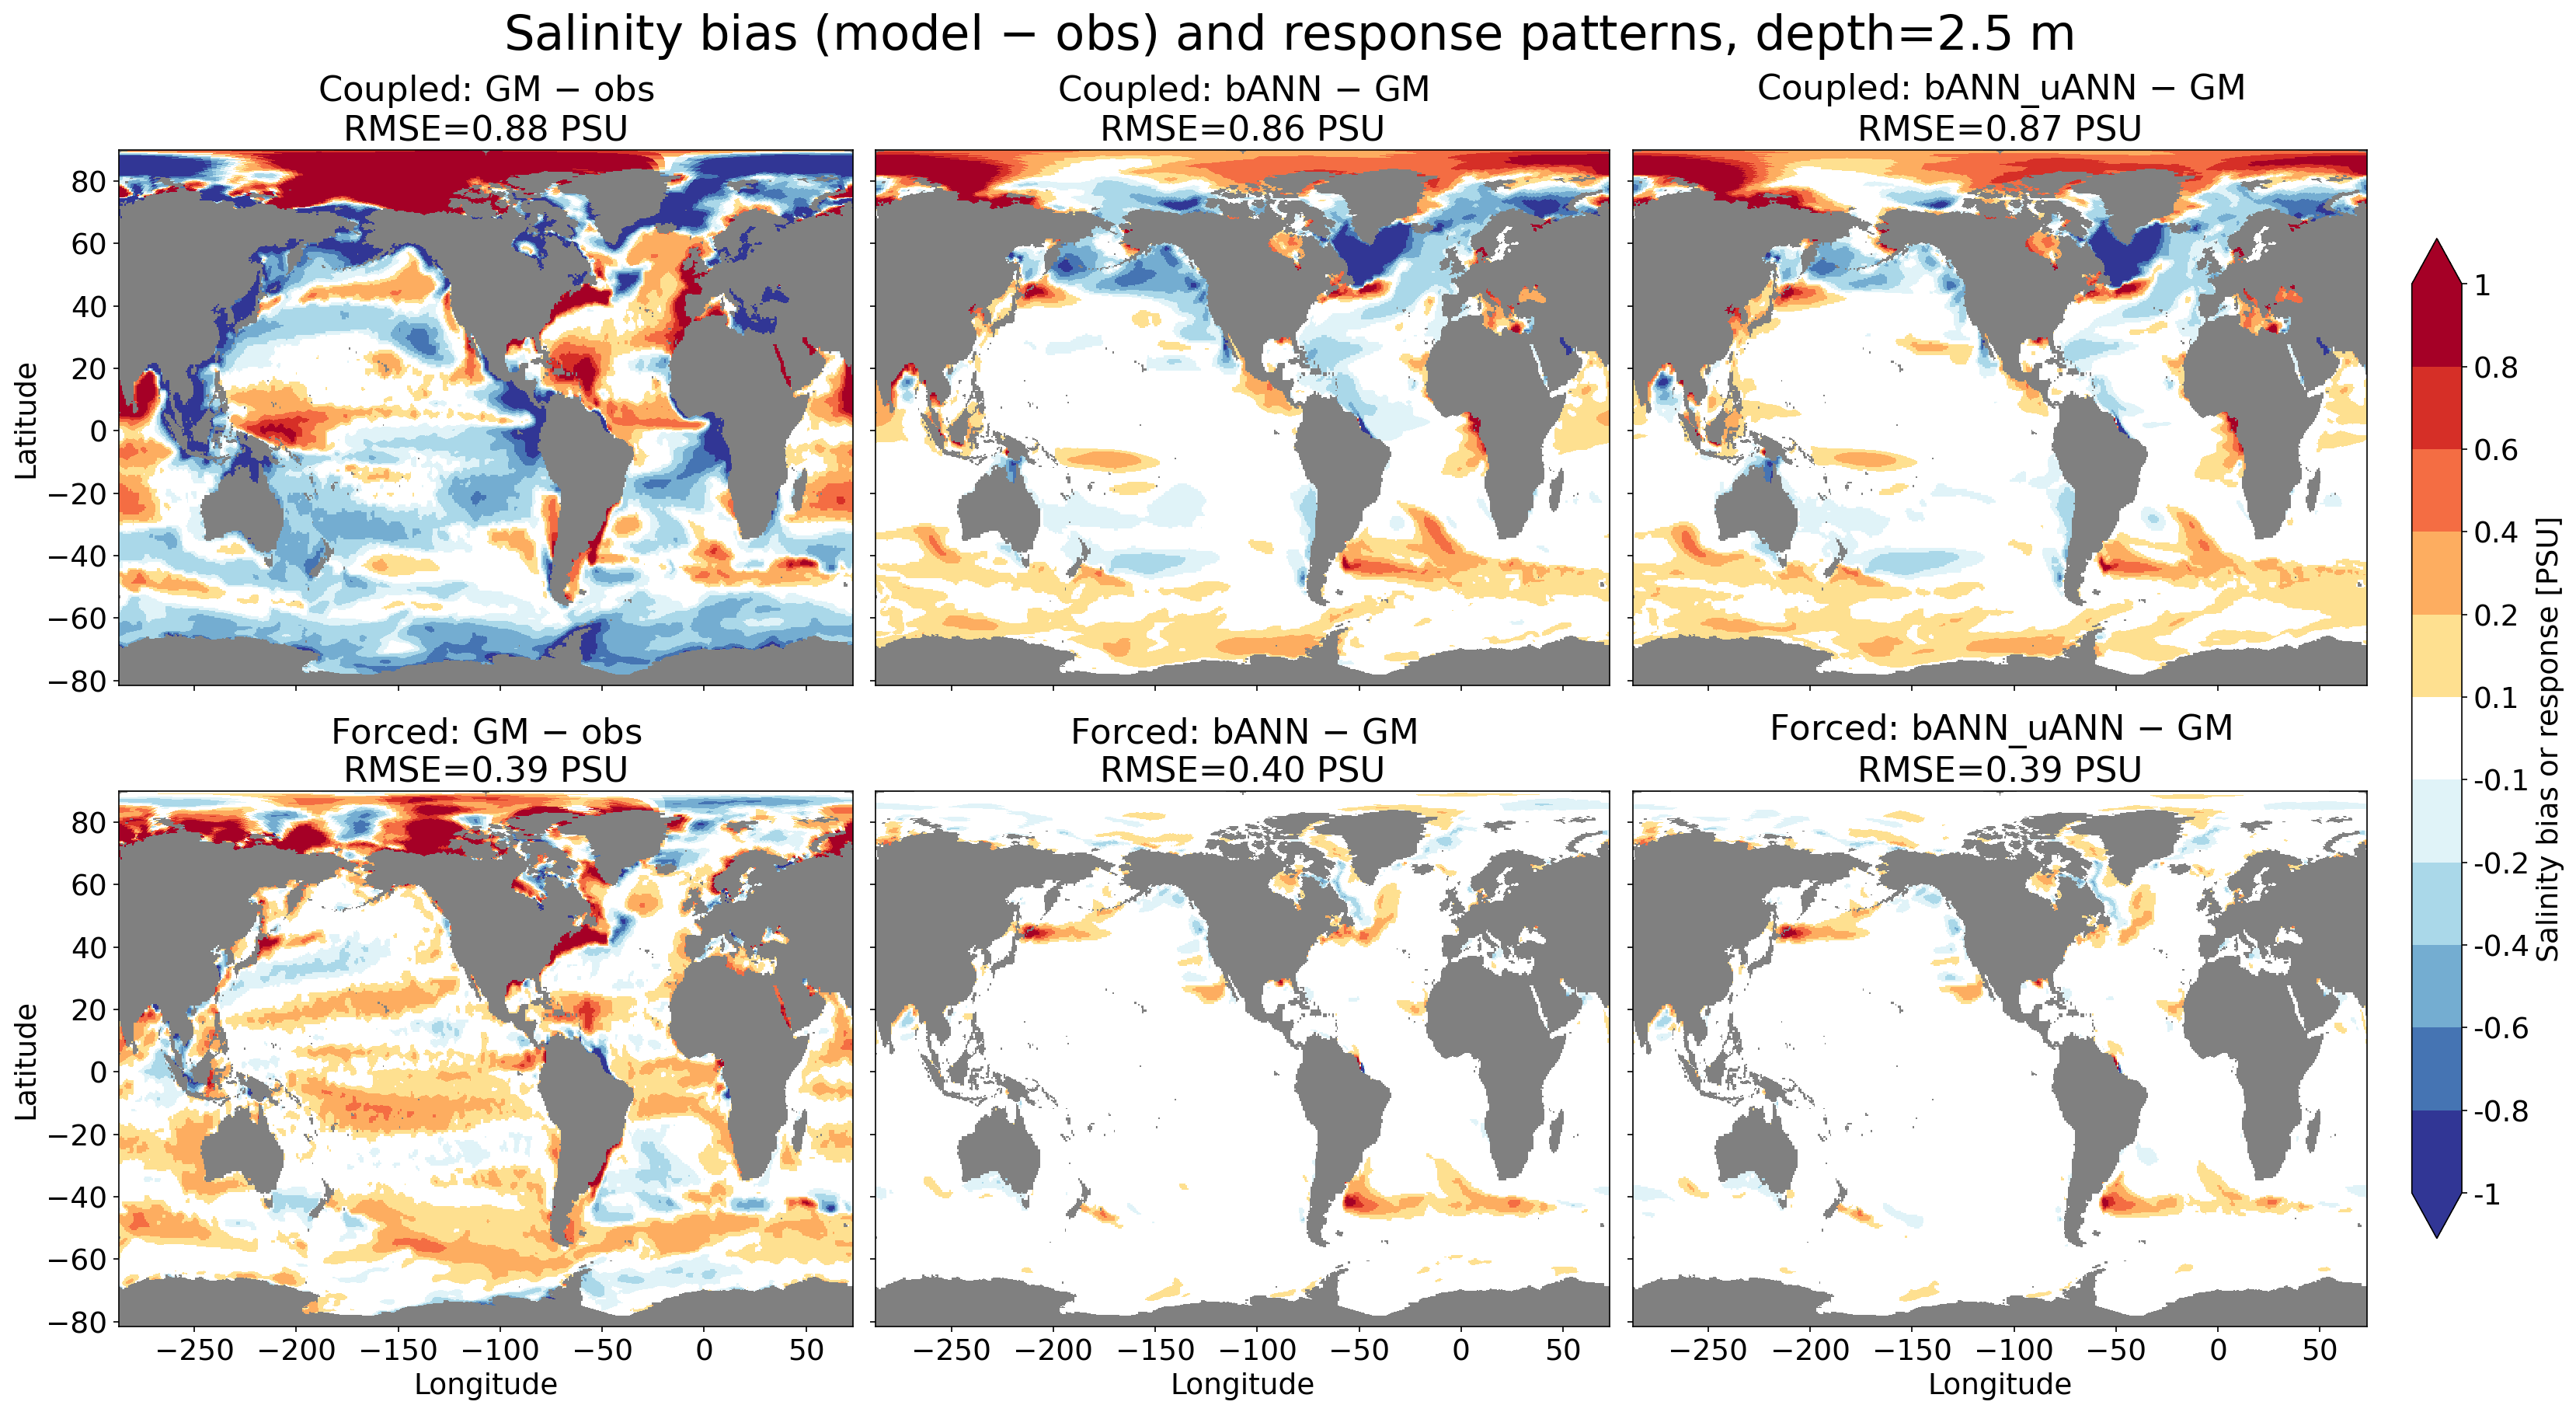

In [40]:
plot_so_bias_maps(2.5)   # surface (nearest z_l = 2.5 m)


# 4. Salinity bias (model - obs) at 250 m

Same diagnostic as section 3, but at ~250 m depth
(`z_l` selected by nearest value) instead of the surface.


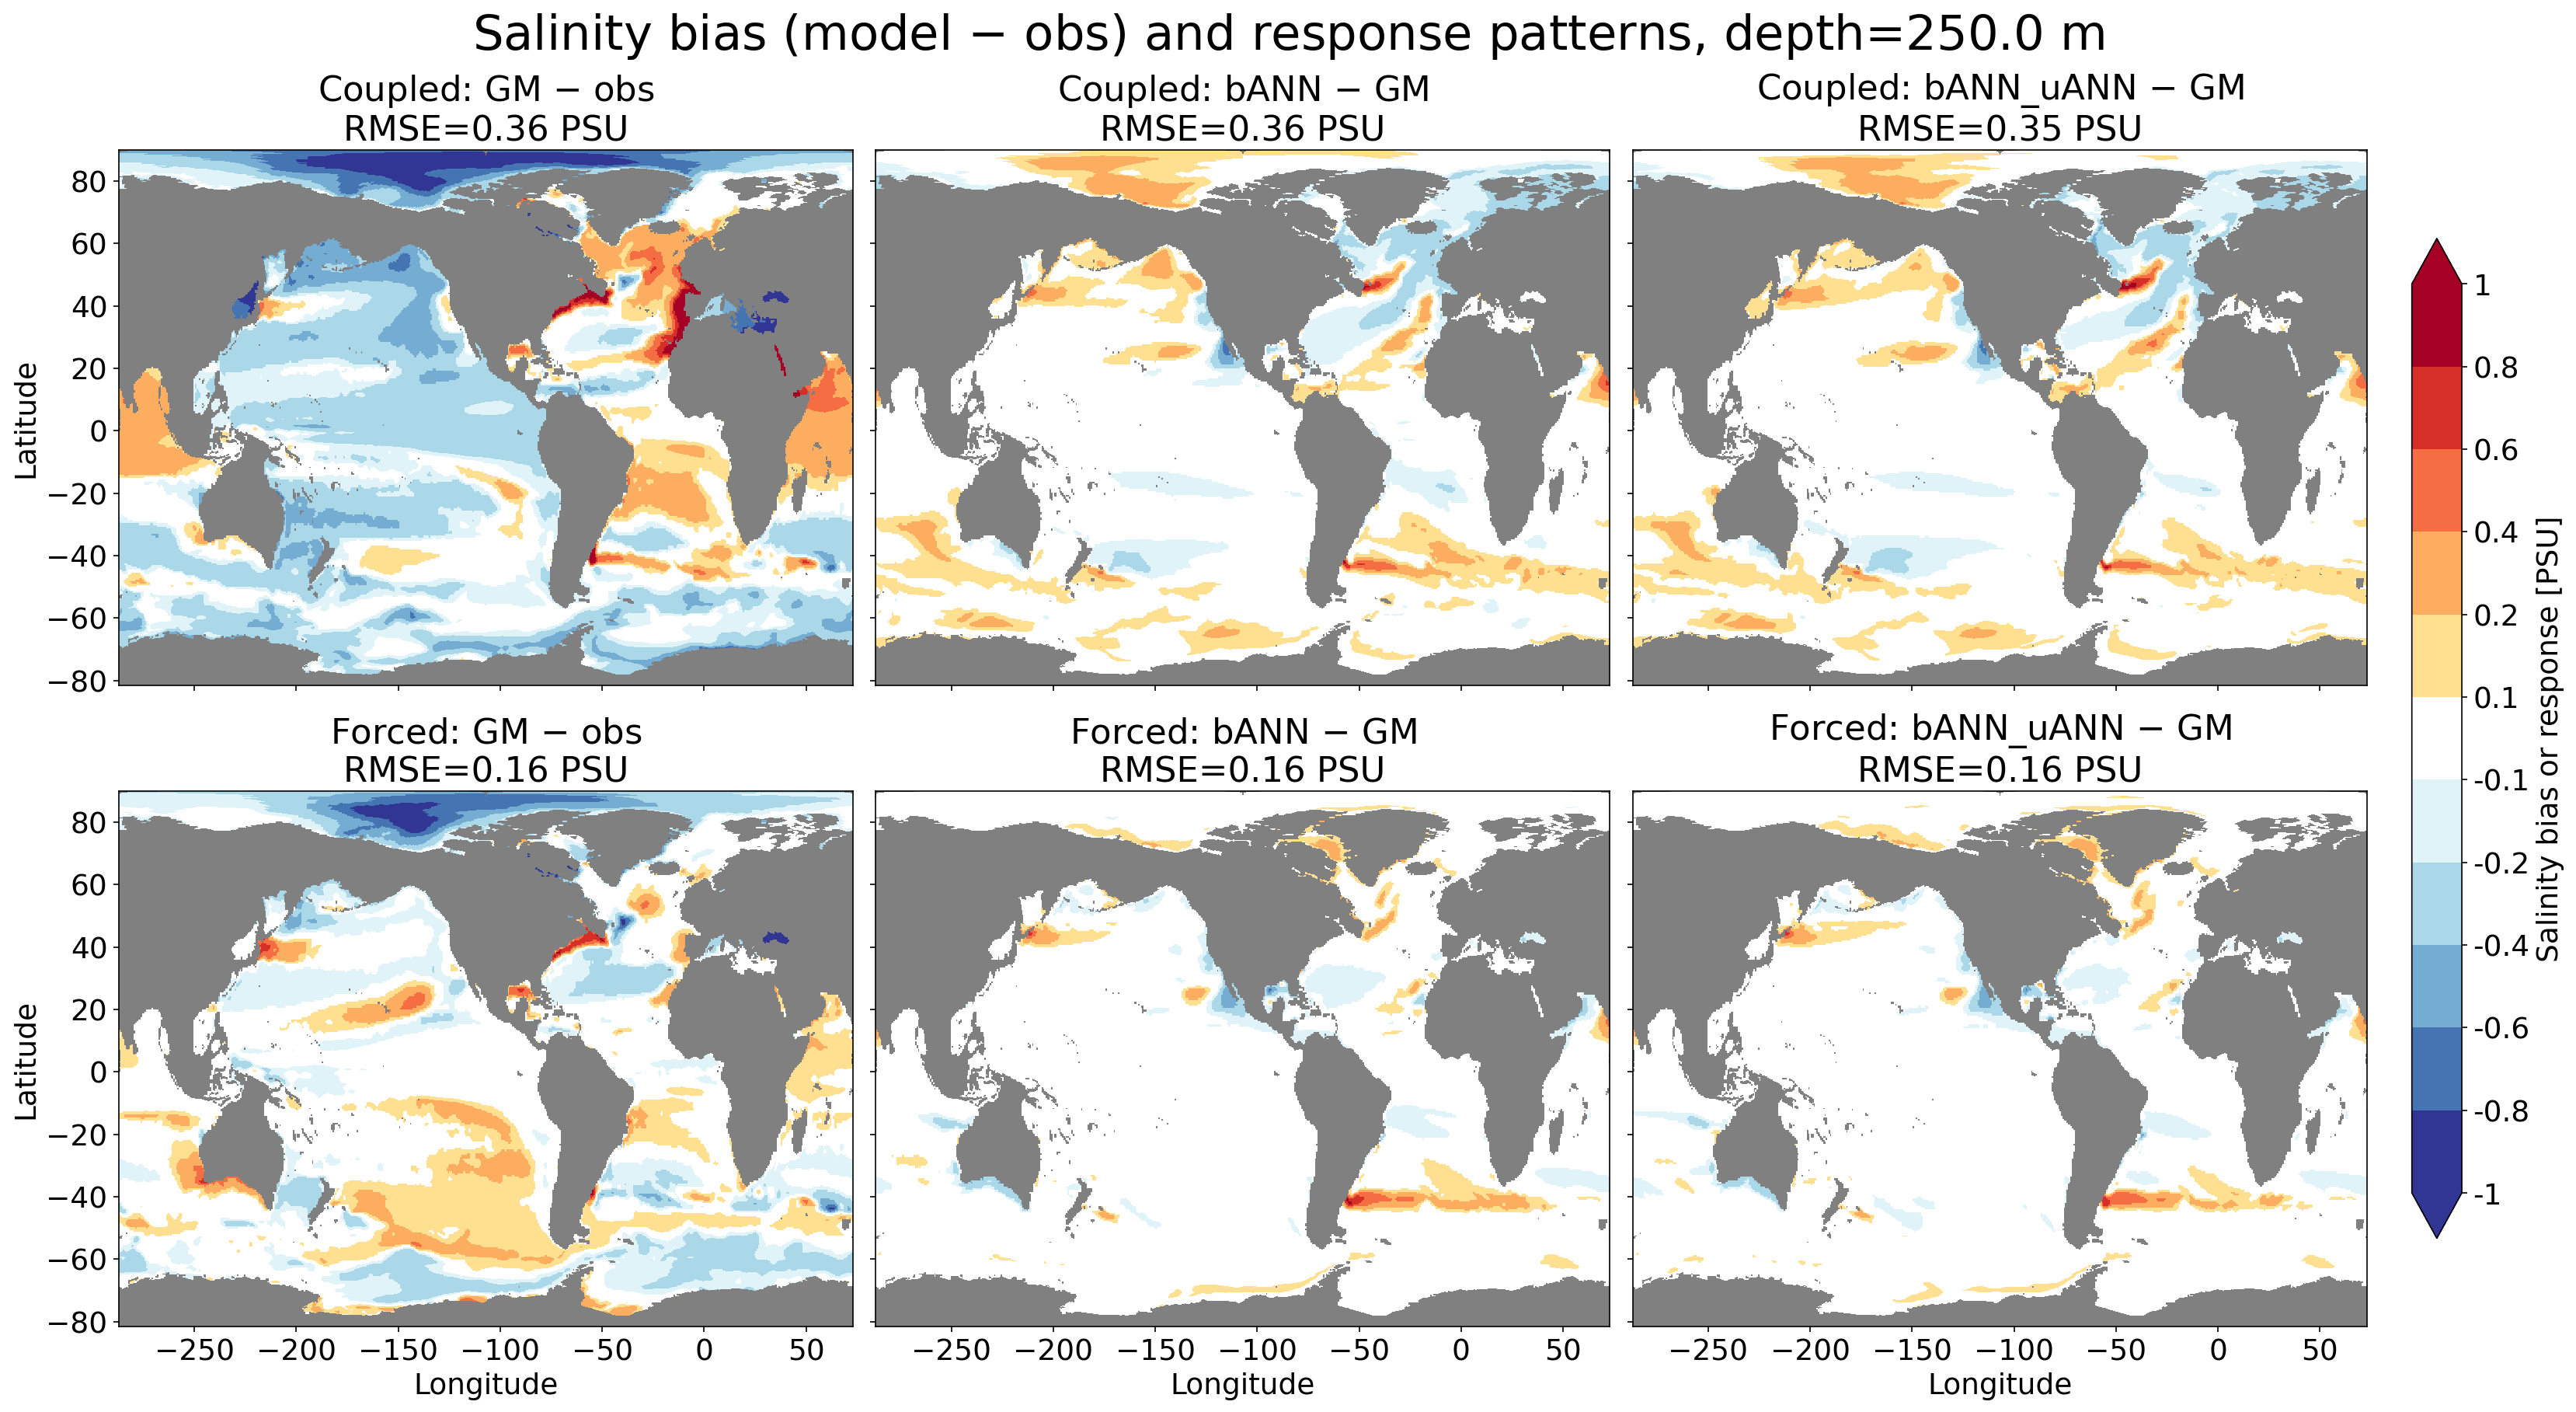

In [41]:
# Same diagnostic as section 3, at ~250 m (nearest z_l level).
plot_so_bias_maps(250.0)


# 5. Zonally-averaged temperature bias (model $-$ obs) and response

Latitude–depth sections of the zonal-average temperature bias, mirroring
section 1 but averaged over longitude into 1° latitude bands via `zonal_ave`
(following `notebooks-development/compare_runs_coupled.ipynb`). Column 1 shows
the GM bias (`model $-$ obs`); columns 2–3 show each experiment's response
(`exp $-$ GM`). RMSE is always the RMS of the zonally-averaged `model $-$ obs`
bias. The depth axis is piecewise-linear (0–200, 200–1000, 1000–5500 m, each
band spanning one third of the height).


In [51]:
# --- Zonally-averaged bias / response sections (latitude vs depth) ---
# Reuses the precomputed model - obs bias fields; the zonal average and
# depth-axis styling follow notebooks-development/compare_runs_coupled.ipynb.

def zonal_ave(array, geolat):
    """Bin a field into 1-degree latitude bands using true geolat (tripolar-safe)."""
    bins = array.yh.values
    bins = (bins[:-1] + bins[1:]) / 2
    return array.groupby_bins(geolat, bins=bins).mean()

# Piecewise-linear depth axis: 0-200, 200-1000, 1000-5500 m each get 1/3 of the height
d_edges = [0, 200, 1000, 5500]

def _depth_forward(d):
    d = np.asarray(d, dtype=float)
    return np.where(d <= d_edges[1], (d - d_edges[0]) / (d_edges[1] - d_edges[0]) / 3,
           np.where(d <= d_edges[2], 1 / 3 + (d - d_edges[1]) / (d_edges[2] - d_edges[1]) / 3,
                    2 / 3 + (d - d_edges[2]) / (d_edges[3] - d_edges[2]) / 3))

def _depth_inverse(y):
    y = np.asarray(y, dtype=float)
    return np.where(y <= 1 / 3, d_edges[0] + y * 3 * (d_edges[1] - d_edges[0]),
           np.where(y <= 2 / 3, d_edges[1] + (y - 1 / 3) * 3 * (d_edges[2] - d_edges[1]),
                    d_edges[2] + (y - 2 / 3) * 3 * (d_edges[3] - d_edges[2])))

def plot_bias_zonal(get_bias, diff_levels, cmap, quantity, unit, cbar_label):
    """2x3 latitude-depth zonal-average bias (model - obs) and exp - GM response."""
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=150,
                             sharex=True, sharey=True, constrained_layout=True)
    im = None
    for row, (regime, names) in enumerate([('Coupled', coupled_row),
                                           ('Forced', forced_row)]):
        geolat = exps[names[0]].grd.geolat
        gm_bias = get_bias(exps[names[0]])            # (z_l, yh, xh) = model - obs
        for col, name in enumerate(names):
            ax = axes[row, col]
            bias = get_bias(exps[name])
            bias_za = zonal_ave(bias, geolat)
            if col == 0:
                field_za = bias_za
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' obs'
            else:
                field_za = zonal_ave(bias - gm_bias, geolat)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
            rmse = float(np.sqrt((bias_za ** 2).mean()))   # RMSE always vs obs
            im = field_za.plot.contourf(ax=ax, levels=diff_levels, cmap=cmap,
                                        extend='both', add_colorbar=False)
            ax.set_title(f'{title}\nRMSE={rmse:.2f} {unit}')
            ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
            ax.set_ylim(d_edges[3], d_edges[0])
            ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])
            for d in (d_edges[1], d_edges[2]):
                ax.axhline(d, color='0.5', lw=0.8, ls='--')
            ax.set_xlim([-80, 80])
            ax.set_xlabel('Latitude' if row == 1 else '')
            ax.set_ylabel('Depth [m]' if col == 0 else '')
    cbar = fig.colorbar(im, ax=axes, label=cbar_label, extend='both',
                        ticks=diff_levels, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in diff_levels])
    fig.suptitle(f'Zonally-averaged {quantity.lower()} bias (model $-$ obs) '
                 'and response patterns', fontsize=30)
    plt.show()

# Temperature zonal levels: same continuous colorbar as the maps, range
# reduced 2x (+/-0.9 degC); 0.0 is not a level boundary.
TZONAL_LEVELS = np.arange(-0.9, 0.91, 0.2)

def plot_thetao_zonal():
    plot_bias_zonal(lambda e: e.thetao().thetao_bias, TZONAL_LEVELS, 'RdYlBu_r',
                    'Temperature', r'$^\circ$C', r'Temperature bias [$^\circ$C]')

# Salinity zonal levels: reuse the maps' neutral-band colorbar (S_CMAP) with the
# range reduced 2x (+/-0.5 PSU) and 0.0 excluded (neutral [-0.05, 0.05] bin).
SZONAL_LEVELS = np.array([-0.5, -0.4, -0.3, -0.2, -0.1, -0.05,
                          0.05, 0.1, 0.2, 0.3, 0.4, 0.5])

def plot_so_zonal():
    plot_bias_zonal(lambda e: e.so().so_bias, SZONAL_LEVELS, S_CMAP,
                    'Salinity', 'PSU', 'Salinity bias [PSU]')

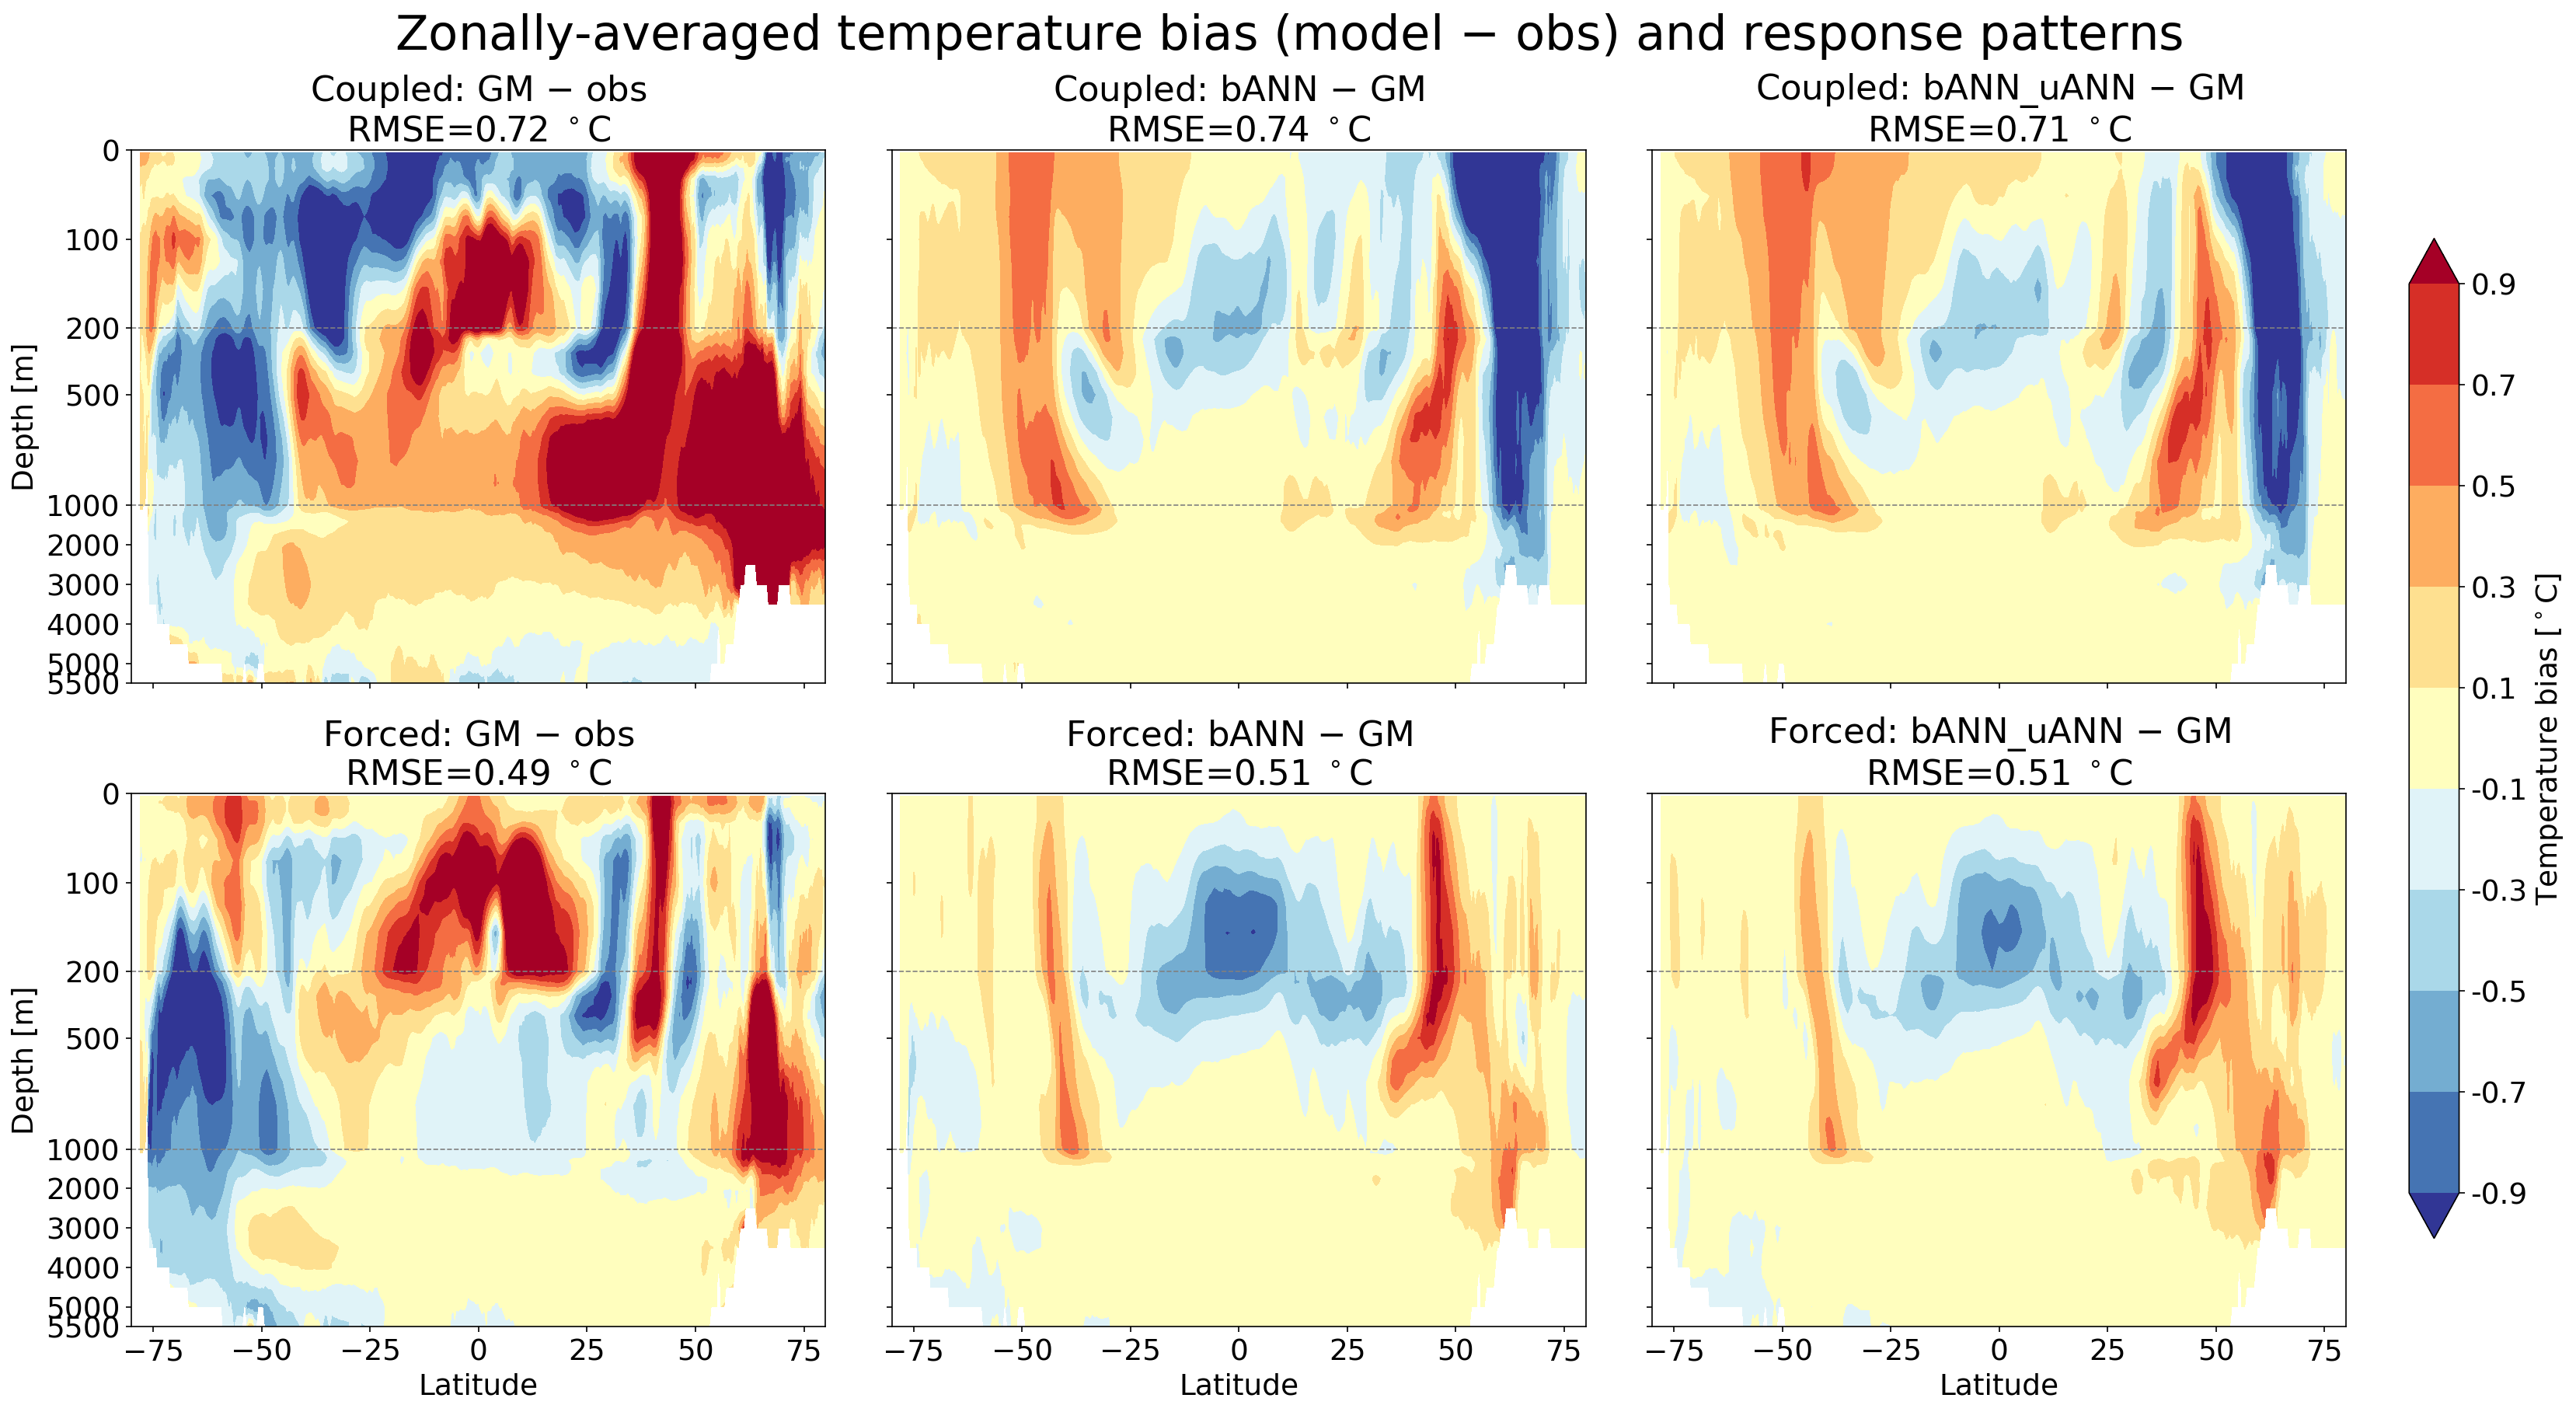

In [52]:
plot_thetao_zonal()

# 6. Zonally-averaged salinity bias (model $-$ obs) and response

Same latitude–depth zonal-average diagnostic as section 5, but for practical
salinity (`so_bias`). Column 1 shows the GM bias (`model $-$ obs`); columns 2–3
show each experiment's response (`exp $-$ GM`). RMSE is always the RMS of the
zonally-averaged `model $-$ obs` bias.


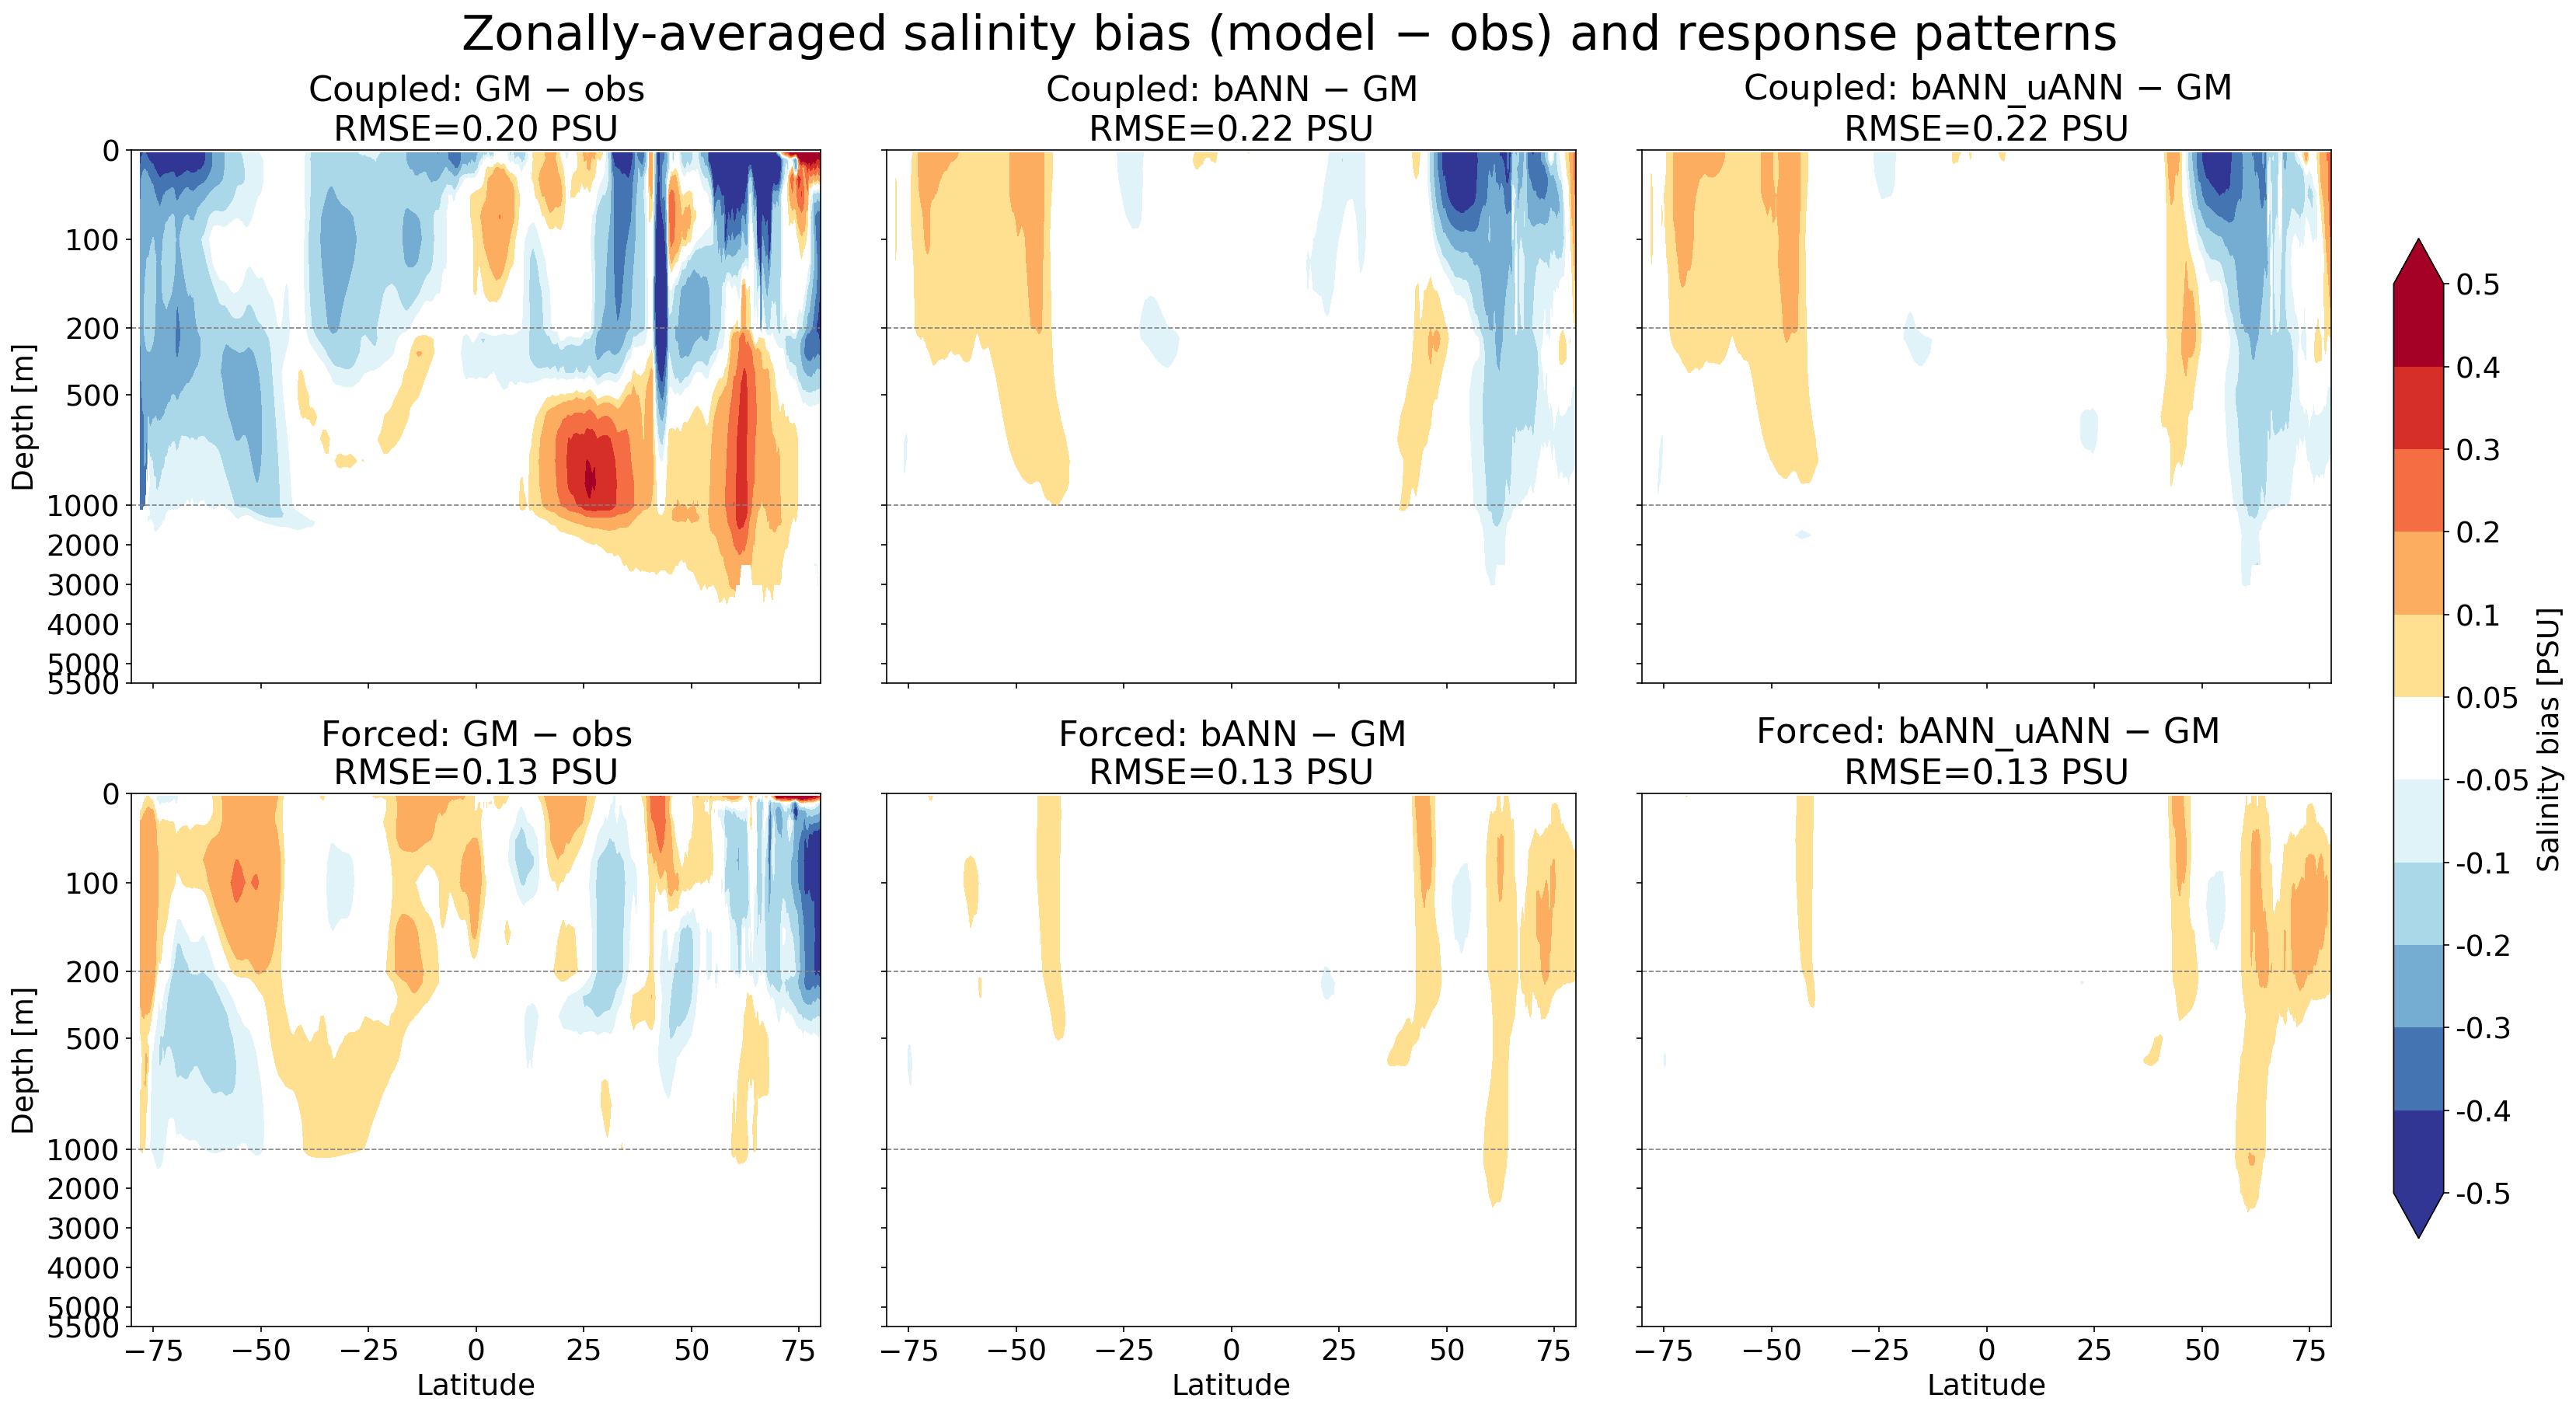

In [53]:
plot_so_zonal()